In [101]:
# import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [102]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [103]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

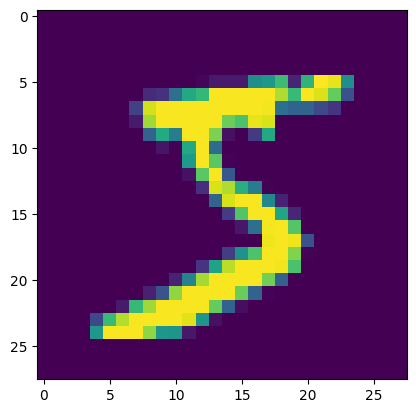

In [104]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [105]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


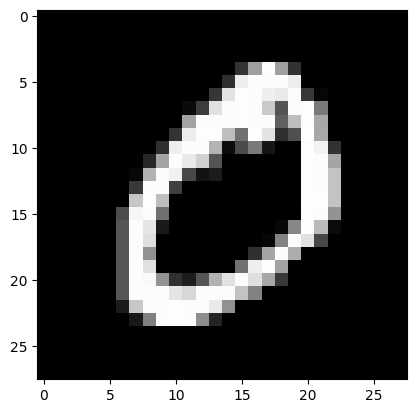

Label = 1


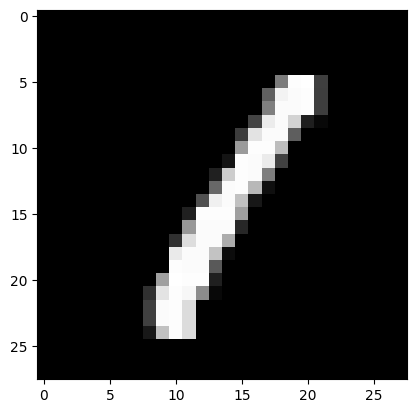

Label = 2


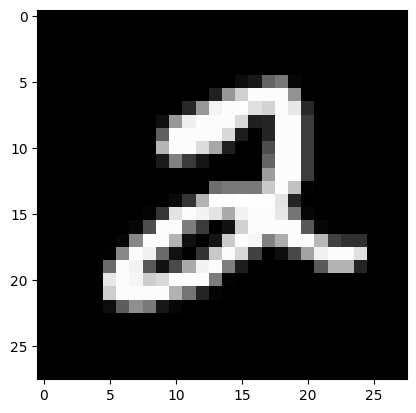

Label = 3


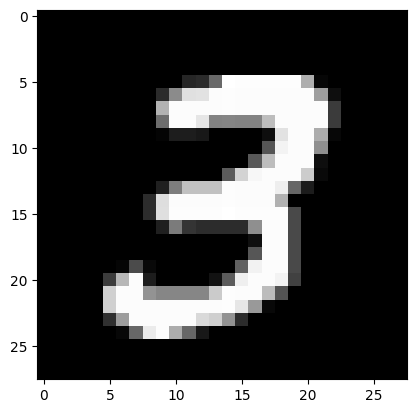

Label = 4


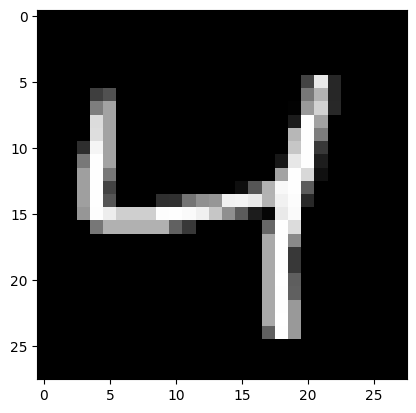

Label = 5


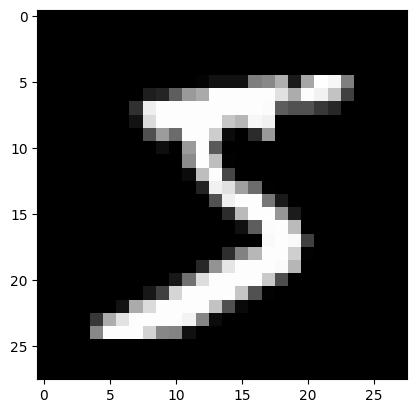

Label = 6


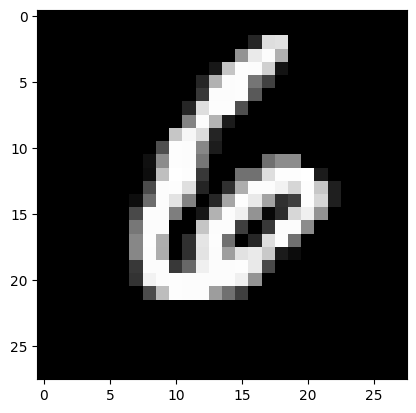

Label = 7


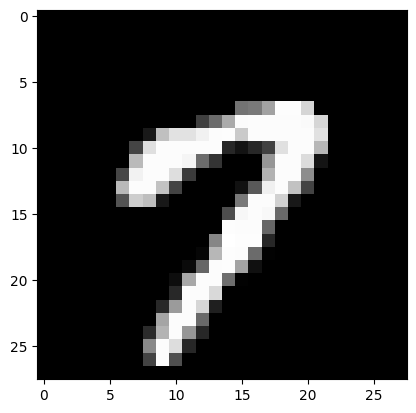

Label = 8


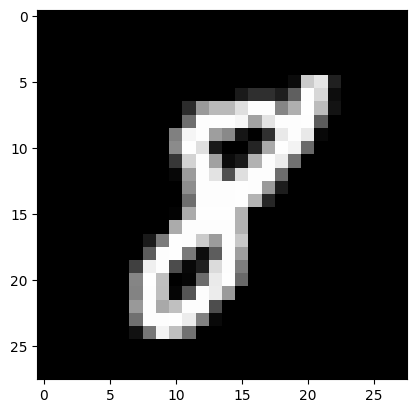

Label = 9


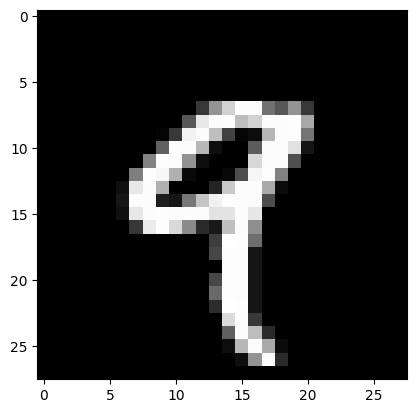

In [106]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx], cmap = 'gray')
            plt.show()
            break
    

In [107]:
# 32 Floating Point data type is used
import sys
mem_fig = sys.getsizeof(data_train[0])
print('The required memory useage for each figure is: {}Byte'.format(mem_fig) )

The required memory useage for each figure is: 128Byte


# Construct the MLP

In [108]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [109]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape=data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)

In [110]:
parameter_by_layer = np.zeros([4])

# layer 1
parameter_by_layer[0] = model.get_layer('dense_1').count_params()
# layer 2
parameter_by_layer[1] = model.get_layer('dense_2').count_params()
# layer 3 
parameter_by_layer[2] = model.get_layer('dense_3').count_params()
# layer 4
parameter_by_layer[3] = model.get_layer('output_layer').count_params()

mem_model = parameter_by_layer.sum() * 32 / 1000
print('The total memory usage for weights and bias is {} kb'.format(mem_model))

The total memory usage for weights and bias is 132.32 kb


In [111]:
# check the parameter numbers
model.summary()

Model: "model_63"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3925      
                                                                 
 act_1 (Activation)          (None, 5)                 0         
                                                                 
 dense_2 (Dense)             (None, 8)                 48        
                                                                 
 act_2 (Activation)          (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 8)                 72 

# Model Training

In [112]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [113]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is reconmmand (10)
r = model.fit(data_train, label_train, validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 [==============================] - 7s 4ms/step - loss: 0.9959 - accuracy: 0.6712 - val_loss: 0.6024 - val_accuracy: 0.8249
Epoch 2/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5781 - accuracy: 0.8282 - val_loss: 0.5123 - val_accuracy: 0.8503
Epoch 3/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.5086 - accuracy: 0.8529 - val_loss: 0.4606 - val_accuracy: 0.8687
Epoch 4/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4621 - accuracy: 0.8671 - val_loss: 0.4211 - val_accuracy: 0.8815
Epoch 5/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4210 - accuracy: 0.8795 - val_loss: 0.3859 - val_accuracy: 0.8888
Epoch 6/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3909 - accuracy: 0.8889 - val_loss: 0.3635 - val_accuracy: 0.8968
Epoch 7/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3721 - accuracy: 0.8951 - val_loss: 0.3517 - val_accuracy:

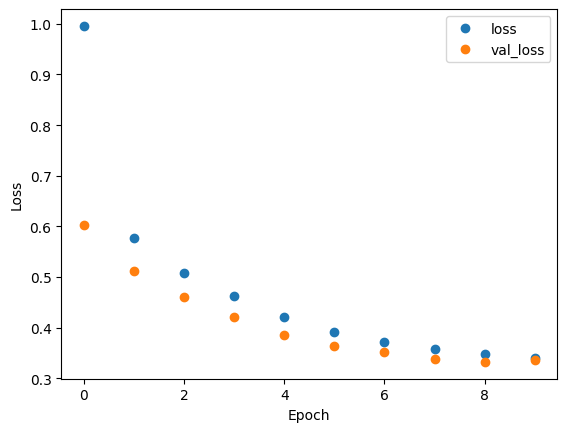

In [114]:
# plot loss
plt.plot(r.history['loss'], 'o', label='loss')
plt.plot(r.history['val_loss'], 'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

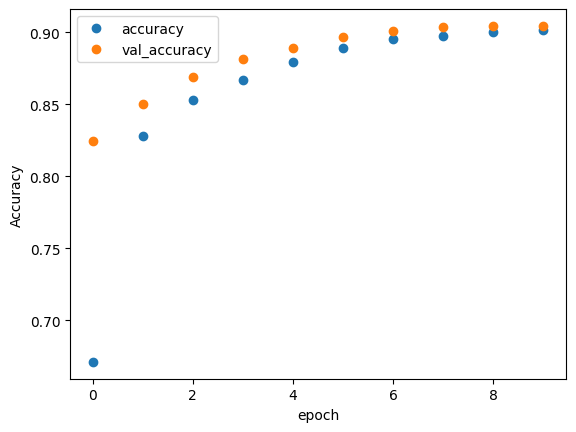

In [115]:
# Plot accuracy
plt.plot(r.history['accuracy'], 'o', label='accuracy')
plt.plot(r.history['val_accuracy'], 'o', label='val_accuracy')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [116]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Training Accuracy: ", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Testing Accuracy: ", acc_floatingpoint )

1875/1875 [==============================] - 4s 2ms/step - loss: 0.3327 - accuracy: 0.9045
Training Accuracy:  0.904533326625824
313/313 [==============================] - 1s 3ms/step - loss: 0.3430 - accuracy: 0.9033
Testing Accuracy:  0.9032999873161316


In [117]:
# save model weights
model.save_weights("weights_FP.weights.h5")

Text(0, 0.5, 'Amount')

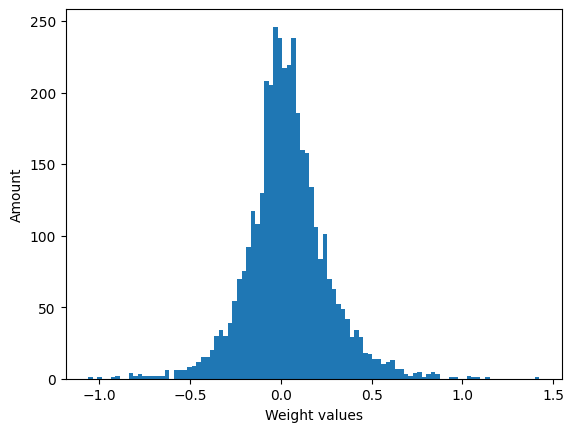

In [118]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

In [119]:
# What can you observe from the distribution of weights?

# The weights all being close to zero pave the way for a nice fixed point quantization.

# Implement of the trained MLP with numpy

In [120]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    # input_mat: (out_features, in_features)
    # input_vec: (in_features,)
    # bias: (out_features,)
    return input_mat @ input_vec + bias

In [121]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    return np.maximum(0, in_activations)

In [122]:
# implement the softmax activation function
def softmax_layer(in_activations):
    # in_activations: (n,)
    exp_z = np.exp(in_activations)
    return exp_z / np.sum(exp_z)

In [123]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented
input_example_np = np.ones([28*28])

W1, b1 = model.layers[2].get_weights()
W2, b2 = model.layers[4].get_weights()
W3, b3 = model.layers[6].get_weights()
W4, b4 = model.layers[8].get_weights()

output_1 = ReLU_layer(dense_layer(input_example_np, W1, b1))
output_2 = ReLU_layer(dense_layer(output_1, W2, b2))
output_3 = ReLU_layer(dense_layer(output_2, W3, b3))
output_4 = softmax_layer(dense_layer(output_3, W4, b4))

In [162]:
# Display your own results
output_4

array([1.67917365e-23, 2.22099812e-25, 7.71756249e-19, 1.00000000e+00,
       1.29642836e-89, 7.73526541e-18, 1.43064196e-50, 3.85228076e-46,
       2.57058165e-22, 2.00442216e-75])

In [125]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 [==============================] - 0s 140ms/step


array([[1.6791946e-23, 2.2209824e-25, 7.7175796e-19, 1.0000000e+00,
        0.0000000e+00, 7.7352678e-18, 0.0000000e+00, 0.0000000e+00,
        2.5705768e-22, 0.0000000e+00]], dtype=float32)

# MLP fixed point quantization

In [126]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [163]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    # int_BW must NOT include the sign bit
    resolution_ = 2**(- frac_BW)
    range_ = 2**(int_BW)
    
    weight = deepcopy(input_weight)
    
    input_weight_clipped = np.clip(weight, - range_, range_ - resolution_)
    input_weight_quantized = np.round(input_weight_clipped/resolution_) * resolution_
    
    return input_weight_quantized

In [164]:
# weight_quantization
BW_int = 1
BW_frac = 6

In [170]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [171]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

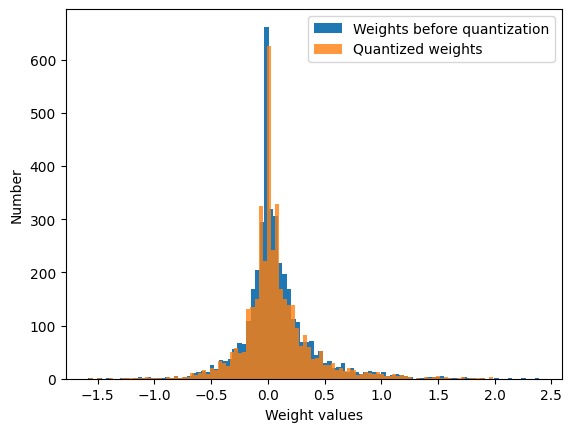

In [172]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [173]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [177]:
# load weights and save 
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int_{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [178]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [179]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 [==============================] - 4s 2ms/step - loss: 0.4403 - accuracy: 0.8643
Train Acc 0.8643166422843933
313/313 [==============================] - 1s 2ms/step - loss: 0.4538 - accuracy: 0.8619
Test Acc: 0.8618999719619751


In [180]:
# Summary
# 32 FP numbers utilized in baseline model
saved_memory = 1 - (1 + BW_int + BW_frac) / 32
acc_drop = acc_floatingpoint - acc_quantized

In [181]:
print("Saved memory: {}%".format(saved_memory*100))
print("Accuracy drop: {:.2f}%".format(acc_drop*100))

Saved memory: 75.0%
Accuracy drop: 4.14%


# Systematic evaluation

In [182]:
model.load_weights("weights_FP.weights.h5")

In [183]:
# parameter sweep, look for the optimal combination
BW_int = 1
acc_quantized_BW_int_1 = np.zeros(31)
saved_memory_BW_int_1  = np.zeros(31)

original_weights = [deepcopy(w) for w in model.get_weights()] # true floating-point weights, captured once

for i in range(31):
    BW_frac = i
     
    weight_quantized = [np.copy(w) for w in original_weights]
    for j in range(len(weight_quantized)): # quantize weights layer by layer
        weight_quantized[j] = fixP_quantization(weight_quantized[j], BW_int, BW_frac)
    
        
    
    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # load quantized weights
    # model_quantized.save_weights("weights_q_int{}_frac_{}.h5".format(BW_int, BW_frac)) # save quantized weights
    
    model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # compile model
    
    print("BW_int = {} BW_frac = {} " .format(BW_int, BW_frac))
    acc_quantized_BW_int_1[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_1[i] = 1 - (BW_int + BW_frac) / 32  # save memory evaluation
    print("The saved memory is {}" .format(saved_memory_BW_int_1[i]))

BW_int = 1 BW_frac = 0 
313/313 [==============================] - 1s 3ms/step - loss: 7.2542 - accuracy: 0.0971
The saved memory is 0.96875
BW_int = 1 BW_frac = 1 
313/313 [==============================] - 1s 3ms/step - loss: 3.8368 - accuracy: 0.3557
The saved memory is 0.9375
BW_int = 1 BW_frac = 2 
313/313 [==============================] - 1s 2ms/step - loss: 1.3824 - accuracy: 0.6514
The saved memory is 0.90625
BW_int = 1 BW_frac = 3 
313/313 [==============================] - 1s 2ms/step - loss: 0.3744 - accuracy: 0.8923
The saved memory is 0.875
BW_int = 1 BW_frac = 4 
313/313 [==============================] - 1s 3ms/step - loss: 0.3594 - accuracy: 0.8942
The saved memory is 0.84375
BW_int = 1 BW_frac = 5 
313/313 [==============================] - 1s 2ms/step - loss: 0.3451 - accuracy: 0.9025
The saved memory is 0.8125
BW_int = 1 BW_frac = 6 
313/313 [==============================] - 1s 3ms/step - loss: 0.3464 - accuracy: 0.9024
The saved memory is 0.78125
BW_int = 1 BW_fra

In [ ]:
# parameter sweep, look for the optimal combination
BW_int = 1
acc_quantized_BW_int_1 = np.zeros(31)
saved_memory_BW_int_1  = np.zeros(31)

for i in range(31):
    BW_frac = i

    weight_quantized = [fixP_quantization(deepcopy(w), BW_int, BW_frac) for w in model.get_weights()] # quantize weights layer by layer

    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # set quantized weights
    model_quantized.save_weights("weights_int{}_frac{}.weights.h5".format(BW_int, BW_frac)) # save quantized weights

    model_quantized.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy']) # compile model

    # r = model.fit(data_train, label_train, validation_split= 0.2, epochs=10)
    # r.history['accuracy']
    # test_accuracy = model.evaluate(data_test, label_test)[1]

    print("BW_int = {}, BW_frac = {}".format(BW_int, BW_frac))
    acc_quantized_BW_int_1[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_1[i] = sys.getsizeof(weight_quantized[2:9:2]) / mem_model # save memory evaluation
    print("The saved memory is {}".format(saved_memory_BW_int_1[i]))

BW_int = 1, BW_frac = 0
313/313 [==============================] - 1s 2ms/step - loss: 3.2927 - accuracy: 0.1128
The saved memory is 0.6045949214026602
BW_int = 1, BW_frac = 1
313/313 [==============================] - 1s 2ms/step - loss: 3.2927 - accuracy: 0.1128
The saved memory is 0.6045949214026602
BW_int = 1, BW_frac = 2
313/313 [==============================] - 1s 2ms/step - loss: 3.2927 - accuracy: 0.1128
The saved memory is 0.6045949214026602
BW_int = 1, BW_frac = 3
313/313 [==============================] - 1s 2ms/step - loss: 3.2927 - accuracy: 0.1128
The saved memory is 0.6045949214026602
BW_int = 1, BW_frac = 4
313/313 [==============================] - 1s 3ms/step - loss: 3.2927 - accuracy: 0.1128
The saved memory is 0.6045949214026602
BW_int = 1, BW_frac = 5
313/313 [==============================] - 1s 3ms/step - loss: 3.2927 - accuracy: 0.1128
The saved memory is 0.6045949214026602
BW_int = 1, BW_frac = 6
313/313 [==============================] - 1s 3ms/step - loss: 3

Text(0.5, 1.0, 'BW_int = 1')

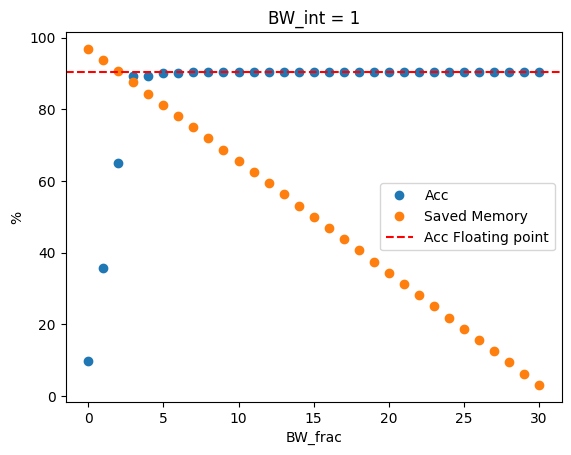

In [184]:
# result visualization
plt.plot(acc_quantized_BW_int_1*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_1*100, 'o', label = 'Saved Memory')
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.legend()
plt.title("BW_int = 1")

In [185]:
# parameter sweep
BW_int = 2
acc_quantized_BW_int_2 = np.zeros(30)
saved_memory_BW_int_2  = np.zeros(30)

original_weights = [deepcopy(w) for w in model.get_weights()] # true floating-point weights, captured once

for i in range(30):
    BW_frac = i
     
    weight_quantized = [np.copy(w) for w in original_weights]
    for j in range(len(weight_quantized)): # quantize weights layer by layer
        weight_quantized[j] = fixP_quantization(weight_quantized[j], BW_int, BW_frac)
    
        
    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # load quantized weights
    model_quantized.save_weights("weights_q_int{}_frac_{}.h5".format(BW_int, BW_frac)) # save quantized weights
    
    model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # compile model
    
    print("BW_int = {} BW_frac = {} " .format(BW_int, BW_frac))
    acc_quantized_BW_int_2[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_2[i] = 1 - (BW_int + BW_frac) / 32  # save memory evaluation
    print("The saved memory is {}" .format(saved_memory_BW_int_2[i]))

BW_int = 2 BW_frac = 0 
313/313 [==============================] - 1s 3ms/step - loss: 7.2542 - accuracy: 0.0971
The saved memory is 0.9375
BW_int = 2 BW_frac = 1 
313/313 [==============================] - 1s 2ms/step - loss: 3.8368 - accuracy: 0.3557
The saved memory is 0.90625
BW_int = 2 BW_frac = 2 
313/313 [==============================] - 1s 2ms/step - loss: 1.3824 - accuracy: 0.6514
The saved memory is 0.875
BW_int = 2 BW_frac = 3 
313/313 [==============================] - 1s 2ms/step - loss: 0.3744 - accuracy: 0.8923
The saved memory is 0.84375
BW_int = 2 BW_frac = 4 
313/313 [==============================] - 1s 2ms/step - loss: 0.3594 - accuracy: 0.8942
The saved memory is 0.8125
BW_int = 2 BW_frac = 5 
313/313 [==============================] - 1s 2ms/step - loss: 0.3451 - accuracy: 0.9025
The saved memory is 0.78125
BW_int = 2 BW_frac = 6 
313/313 [==============================] - 1s 2ms/step - loss: 0.3464 - accuracy: 0.9024
The saved memory is 0.75
BW_int = 2 BW_frac =

Text(0.5, 1.0, 'BW_int = 2')

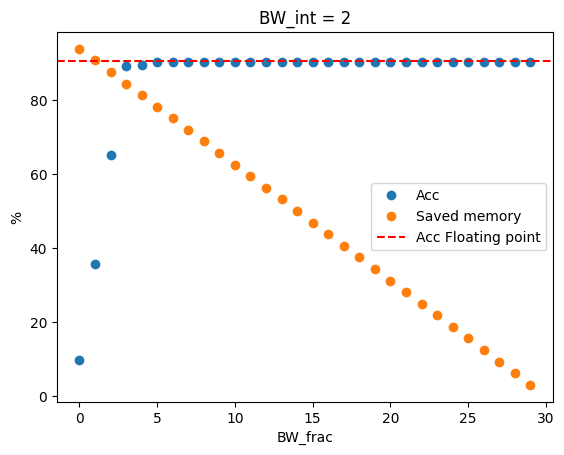

In [186]:
plt.plot(acc_quantized_BW_int_2*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_2*100, 'o', label = 'Saved memory')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.legend()
plt.title("BW_int = 2")

# Pruning

In [187]:
# load lib
# if something goes wrong
# run pip install tensorflow==2.4.1
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude

In [144]:
# parameters for training the pruned model
batch_size = 32
epochs = 10
num_images = 60000
 
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs

In [145]:
# Define model for pruning.
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=0.80,
                                                               begin_step=3000,
                                                               end_step=end_step)
}

In [188]:
pruned_model = prune_low_magnitude(model, **pruning_params)

In [189]:
# `prune_low_magnitude` requires a recompile.
pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

pruned_model.summary()

Model: "model_63"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n_1 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_act_1   (None, 5)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90        
 2 (PruneLowMagnitude)                                    

 prune_low_magnitude_act_2   (None, 8)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 138       
 3 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_act_3   (None, 8)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_output  (None, 10)                172       
 _layer (PruneLowMagnitude)                                      
                                                                 
 prune_low_magnitude_softma  (None, 10)                1         
 x (PruneLowMagnitude)                                           
                                                                 
Total para

In [199]:
#Keras callback which updates pruning wrappers with the optimizer step. 
#This callback must be used when training a model which needs to be pruned. Not doing so will throw an error.

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),]


history = pruned_model.fit(data_train,
                           label_train,
                           batch_size=batch_size,
                           epochs=epochs, 
                           validation_split = 0.20,
                           callbacks=callbacks)

Epoch 1/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3108 - accuracy: 0.9105 - val_loss: 0.3157 - val_accuracy: 0.9053
Epoch 2/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3094 - accuracy: 0.9102 - val_loss: 0.3198 - val_accuracy: 0.9068
Epoch 3/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3097 - accuracy: 0.9104 - val_loss: 0.3113 - val_accuracy: 0.9099
Epoch 4/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3068 - accuracy: 0.9107 - val_loss: 0.3106 - val_accuracy: 0.9097
Epoch 5/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3058 - accuracy: 0.9112 - val_loss: 0.3200 - val_accuracy: 0.9086
Epoch 6/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.3051 - accuracy: 0.9118 - val_loss: 0.3115 - val_accuracy: 0.9099
Epoch 7/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3033 - accuracy: 0.9126 - val_loss: 0.3079 - val_accuracy:

In [191]:
acc_pruned_model = pruned_model.evaluate(data_test, label_test)[1]

313/313 [==============================] - 1s 3ms/step - loss: 0.3315 - accuracy: 0.9058


In [192]:
pruned_model.summary()

Model: "model_63"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n_1 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_act_1   (None, 5)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90        
 2 (PruneLowMagnitude)                                    

Text(0, 0.5, 'Amount')

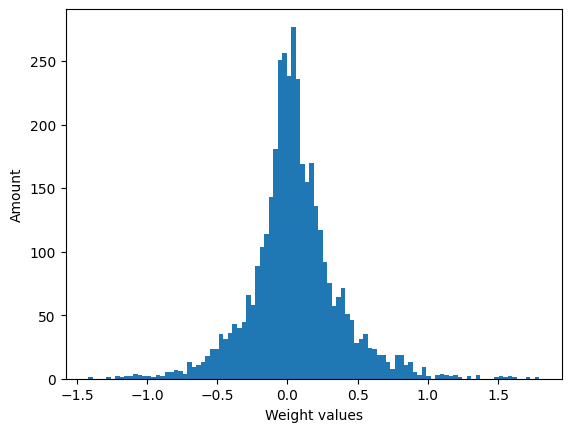

In [193]:
# display the weights in 1st layer of the pruned model
_ = plt.hist((pruned_model.get_weights()[1]).flatten(), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

Text(0, 0.5, 'Amount')

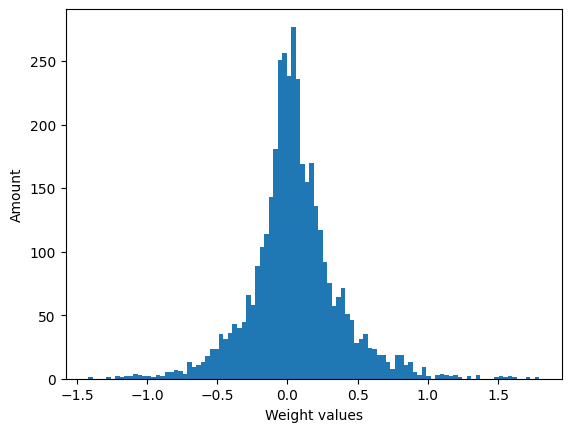

In [194]:
# compare with the original model
_ = plt.hist((model.get_weights()[0]).flatten(), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

In [195]:
# calculate the saved memory
# simple assumption: "0" doesn't occupy any space

In [210]:
# compute the saved memory space 
weights_total = 0
weights_pruned = 0
get_weights_idx = [3, 9, 15, 21]
for i in range(4):
    weights_total  += pruned_model.get_weights()[get_weights_idx[i]].size
    weights_pruned += pruned_model.get_weights()[get_weights_idx[i]].sum()

weights_pruned_remained = weights_pruned # remianing weights in the pruned mode

In [207]:
acc_drop_prun = acc_floatingpoint - acc_pruned_model 

In [208]:
print("The saved memory space by pruning is {:.3f}%".format((1-weights_pruned_remained/weights_total)*100))
print("The accuracy drop is {:.3f}pp".format(acc_drop_prun*100))

The saved memory space by pruning is 88.791%
The accuracy drop is -0.250pp


# Systematic evaluation

In [201]:
sparisty_vec = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
acc_prun_vec = np.zeros(len(sparisty_vec))

In [203]:
for i in range(len(sparisty_vec)):
    # Define model for pruning.
    pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=sparisty_vec[i],
                                                               begin_step=3000,
                                                               end_step=end_step)}
    
    pruned_model = prune_low_magnitude(model, **pruning_params)
    
    pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
    
    callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),]


    history = pruned_model.fit(data_train,
                           label_train,
                           batch_size=batch_size,
                           epochs=epochs, 
                           validation_split = 0.20,
                           callbacks=callbacks)
    
    acc_prun_vec[i] = pruned_model.evaluate(data_test, label_test)[1]
    

Epoch 1/10
1500/1500 [==============================] - 9s 4ms/step - loss: 0.2876 - accuracy: 0.9153 - val_loss: 0.3084 - val_accuracy: 0.9104
Epoch 2/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.2850 - accuracy: 0.9158 - val_loss: 0.3061 - val_accuracy: 0.9114
Epoch 3/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2851 - accuracy: 0.9159 - val_loss: 0.3084 - val_accuracy: 0.9103
Epoch 4/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2837 - accuracy: 0.9177 - val_loss: 0.3092 - val_accuracy: 0.9097
Epoch 5/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2826 - accuracy: 0.9178 - val_loss: 0.3210 - val_accuracy: 0.9075
Epoch 6/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2822 - accuracy: 0.9183 - val_loss: 0.3098 - val_accuracy: 0.9091
Epoch 7/10
1500/1500 [==============================] - 7s 4ms/step - loss: 0.2819 - accuracy: 0.9184 - val_loss: 0.3031 - val_accuracy:

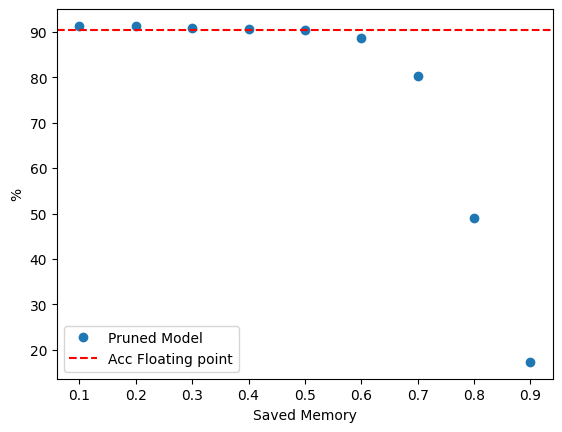

In [204]:
plt.plot(sparisty_vec, acc_prun_vec*100, 'o', label = 'Pruned Model')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('Saved Memory')
plt.ylabel('%')
plt.legend()